In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os

In [2]:

from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


### LiteLLM Configuration

In [ ]:
import os
import litellm

class LiteLLMClient:
    def __init__(self, api_key):
        litellm.api_key = api_key
        litellm.model_list()  # Optional: List available models to verify connection
        litellm.ModelConfig.default_model = "groq/llama-3.3-70b-versatile"  # Set default model

client = LiteLLMClient(api_key=os.getenv("GROQ_API_KEY"))

In [3]:
class State(TypedDict):
    product_name: str
    basic_description: str
    features_benefits: str
    marketing_message: str
    final_description: str

In [4]:
def generate_basic_description(state: State) -> State:
    product_name = state['product_name']
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates product descriptions."},
            {"role": "user", "content": f"Generate a basic description for the product: {product_name}."}
        ]
    )
    basic_description = response.choices[0].message.content.strip()

    return {"basic_description":basic_description}


In [5]:
def add_features_benefits(state: State) -> State:
    basic_description = state['basic_description']

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that adds features and benefits to product descriptions."},
            {"role": "user", "content": f"Based on the basic description: {basic_description}, list the features and benefits of the product."}
        ]
    )
    features_benefits = response.choices[0].message.content.strip()

    return {"features_benefits": features_benefits}





In [6]:
# create image using VLM
def create_image(prompt):
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that creates marketing messages for products."},
            {"role": "user", "content": f"Create a marketing message based on the features and benefits: {state['features_benefits']}."}
        ]
    )



In [7]:
def create_marketing_message(state: State) -> State:
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that creates marketing messages for products."},
            {"role": "user", "content": f"Create a marketing message based on the features and benefits: {state['features_benefits']}."}
        ]
    )
    
    marketing_message = response.choices[0].message.content.strip()
    return {"marketing_message": marketing_message}

In [8]:
def polish_final_description(state: State) -> State:
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that polishes product descriptions."},
            {"role": "user", "content": f"Polish the following product description and marketing message into a final description:\nBasic Description: {state['basic_description']}\nMarketing Message: {state['marketing_message']}"}
        ]
    )
    final_description = response.choices[0].message.content.strip()
    return {"final_description": final_description}

In [9]:
def build_workflow():
    """Builds the state graph workflow for generating product descriptions using LangGraph."""
    workflow = StateGraph[State, State, State](State)
    workflow.add_node("generate_basic_description", generate_basic_description)
    workflow.add_node("add_features_benefits", add_features_benefits)
    workflow.add_node("create_marketing_message", create_marketing_message)
    workflow.add_node("polish_final_description", polish_final_description)

    workflow.add_edge(START, "generate_basic_description")
    workflow.add_edge("generate_basic_description", "add_features_benefits")
    workflow.add_edge("add_features_benefits", "create_marketing_message")
    workflow.add_edge("create_marketing_message", "polish_final_description")

    workflow.add_edge("polish_final_description", END)
    chain = workflow.compile()
    return chain


In [10]:
chain = build_workflow()

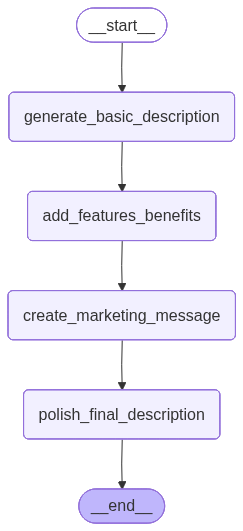

In [11]:

from IPython.display import Image, display

try:
    display(Image(chain.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [12]:
product_name = "Smart Fitness Watch"
state = State(product_name=product_name, basic_description="", features_benefits="", marketing_message="", final_description="")
result = chain.invoke(state)




In [13]:
result

{'product_name': 'Smart Fitness Watch',
 'basic_description': 'The Smart Fitness Watch is a versatile and stylish wearable device designed to help you track and achieve your fitness goals. With advanced features such as heart rate monitoring, step counting, calorie tracking, and sleep analysis, this watch provides valuable insights into your health and wellness. Stay connected with notifications for calls, messages, and social media updates, all conveniently displayed on the vibrant touchscreen display. Enhance your workout experience and stay motivated to reach new levels of fitness with the Smart Fitness Watch.',
 'features_benefits': 'Features and Benefits of the Smart Fitness Watch:\n\n1. **Heart Rate Monitoring**: \n   - *Benefit*: Helps you track your heart rate during workouts to ensure you are training in the right intensity zones for optimal results and safety.\n\n2. **Step Counting**:\n   - *Benefit*: Encourages you to stay active by setting and achieving daily step goals, pr